<a href="https://colab.research.google.com/github/nataprofits/IBM_test_repo/blob/test-from-colab/Implementing_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Step 1: Preprocess data**
Prepare the MNIST data set for training by normalizing the pixel values and reshaping the images to have a single color channel. Normalization helps in faster convergence during training, and reshaping is required because the input layer of your diffusion model expects a three-dimensional tensor.

1. Load and preprocess the MNIST data set:

Use Keras to load the MNIST data set.
Normalize the image pixel values to the range [0, 1].
2. Reshape the Data:

Expand the dimensions of the images to match the input shape required by the model (28x28x1).

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load the data set
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the pixel values
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Expand dimensions to match the input shape (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the values to be within the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


####**Step 2: Build the diffusion model**
Build a simple diffusion model with an encoder that compresses the input image into a latent representation and a decoder that reconstructs the image from this representation. The model is compiled with the Adam optimizer and binary cross-entropy loss.

1. Define the encoder:

Create an input layer with the shape (28, 28, 1).
Add two Conv2D layers with increasing filter sizes and ReLU activation.
2. Define the bottleneck:

Add a flattened layer followed by a dense layer with ReLU activation.
3. Define the decoder:

Add a Dense layer to expand the bottleneck representation.
Reshape the output to match the original image dimensions.
Add two Conv2DTranspose layers with decreasing filter sizes and ReLU activation.
4. Compile the model:

Use the Adam optimizer and binary cross-entropy loss.

In [2]:
input_layer = Input(shape=(28, 28, 1))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)  # Reduced filters
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
x = Flatten()(x)
x = Dense(64, activation='relu')(x)  # Reduced size
x = Dense(28*28*32, activation='relu')(x)  # Reduced size
x = Reshape((28, 28, 32))(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
diffusion_model = Model(input_layer, output_layer)

# Compile the model with mixed precision and a different loss function
diffusion_model.compile(optimizer='adam', loss='mean_squared_error')  # Using MSE for regression tasks

# Summary of the optimized model
diffusion_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25088)               │       1,630,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

####Step 3: Add noise to the data
Add random noise to the data set to simulate the diffusion process:

Add Gaussian noise to the training and test data sets.
Clip the values to ensure they remain within the valid range [0, 1].

In [3]:
# Cache and prefetch the data using TensorFlow data pipelines for faster loading
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))
train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size

val_dataset = tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))
val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size


####Step 4: Train the diffusion model
Train the diffusion model to denoise the MINIST images. Use the noisy images as input and the original images as the target, learning to reverse the noise addition process.

Use the ‘fit’ method to train the model on the noisy training data.
Set the number of epochs to 50 and the batch size to 128.

In [4]:
# Implement early stopping based on validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model with early stopping and smaller batch size
diffusion_model.fit(
    train_dataset,
    epochs=3,
    shuffle=True,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0672 - val_loss: 0.0305
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0254 - val_loss: 0.0264
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0224 - val_loss: 0.0252


####Step 5: Evaluate the diffusion model
Evaluate the performance of the trained diffusion model by predicting the denoised images and visualizing the results. Comparing the original, noisy, and denoised images will help you understand how well the model has learned to remove noise from the images.

1. Reconstruct images:

Use the diffusion model to predict the denoised test images.
Compare the original, noisy, and denoised images.
2. Visualize the results:

Plot a few examples of original, noisy, and denoised images side by side.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


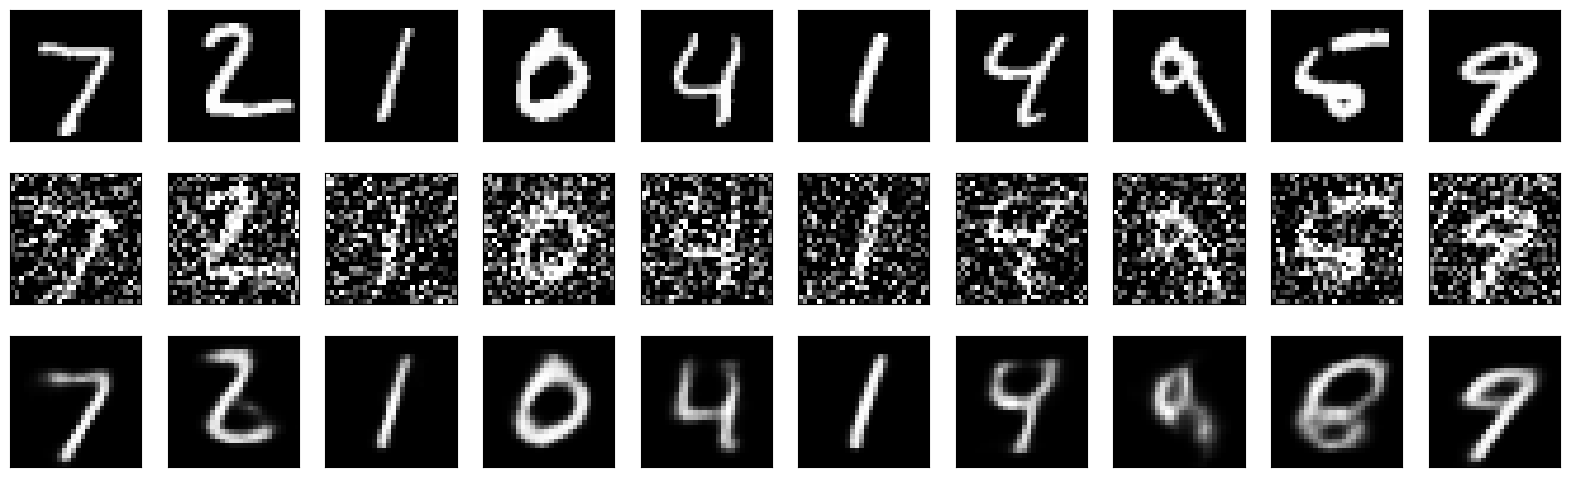

In [5]:
import matplotlib.pyplot as plt

# Predict the denoised images
denoised_images = diffusion_model.predict(x_test_noisy)

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

####Step 6: Fine-tune the diffusion model
Fine-tune the diffusion model by unfreezing some layers and retraining the model to improve its performance.

1. Unfreeze the model layers:

Unfreeze the last few layers of the model to allow them to be retrained.
2. Compile and train the model:

Recompile the model.
Train the model again for an additional 10 epochs.

In [6]:
# Unfreeze the top layers of the model
for layer in diffusion_model.layers[-4:]:
    layer.trainable = True

# Compile the model again
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model again
diffusion_model.fit(x_train_noisy, x_train,
                    epochs=10,
                    batch_size=64,
                    shuffle=True,
                    validation_data=(x_test_noisy, x_test))


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.1250 - val_loss: 0.1203
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1190 - val_loss: 0.1189
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1164 - val_loss: 0.1176
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1149 - val_loss: 0.1172
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1132 - val_loss: 0.1175
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1115 - val_loss: 0.1171
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1107 - val_loss: 0.1167
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.1095 - val_loss: 0.1168
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1087 - val_loss: 0.1173
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1081 - val_loss: 0.1175


###Modify the noise factor
Objective:
Change the noise factor and see how it affects the model’s ability to denoise images.
Instructions:
Change the noise factor to 0.3.
Add noise to the training and test data sets with the new noise factor.
Retrain the model with the new noisy data.

In [7]:
# Add noise to the data with the new noise factor
noise_factor = 0.3
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the values to be within the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

diffusion_model.fit(x_train_noisy, x_train,
                    epochs=50,
                    batch_size=128,
                    shuffle=True,
                    validation_data=(x_test_noisy, x_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.1035 - val_loss: 0.1012
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1007 - val_loss: 0.1005
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1001 - val_loss: 0.1002
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0994 - val_loss: 0.0998
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0991 - val_loss: 0.0995
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0984 - val_loss: 0.0992
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0981 - val_loss: 0.0988
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0978 - val_loss: 0.0987
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0970 - val_loss: 0.0991
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0967 - val_loss: 0.0984
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0963 - val_loss: 0.0985
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━

###Add more layers to the model
Objective:
Experiment with adding more layers to the model to see how it affects performance.
Instructions:
Add an additional Conv2D layer with 128 filters in the encoder.
Add an additional Conv2DTranspose layer with 128 filters in the decoder.
Rebuild, compile, and train the model.

In [9]:
# Modified Model with additional layers
input_layer = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x) # Added Conv2D layer
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dense(28*28*64, activation='relu')(x)
x = Reshape((28, 28, 64))(x)
x = Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(32, (3,3), activation='relu', padding='same')(x) # Added Conv2DTranspose layer
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
diffusion_model = Model(input_layer, output_layer)

diffusion_model.compile(optimizer='adam', loss='mean_squared_error')
diffusion_model.summary()

# Cache and prefetch the data
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))
train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))
val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

diffusion_model.fit(
    train_dataset,
    epochs=3,
    shuffle=True,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 50176)               │       6,472,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_4 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,576,961 (74.68 MB)

 Trainable params: 19,576,961 (74.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step - loss: 0.0428 - val_loss: 0.0079
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - loss: 0.0054 - val_loss: 0.0060


###Visualize the effect of noise
Objective:
Compare the impact of different noise levels on the denoising performance of the model.
#####Instructions:
Add noise with different factors (e.g., 0.1, 0.5, 0.7) to the test data.
Use the model to predict the denoised images for each noise level.
Visualize the original, noisy, and denoised images side by side for each noise level.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


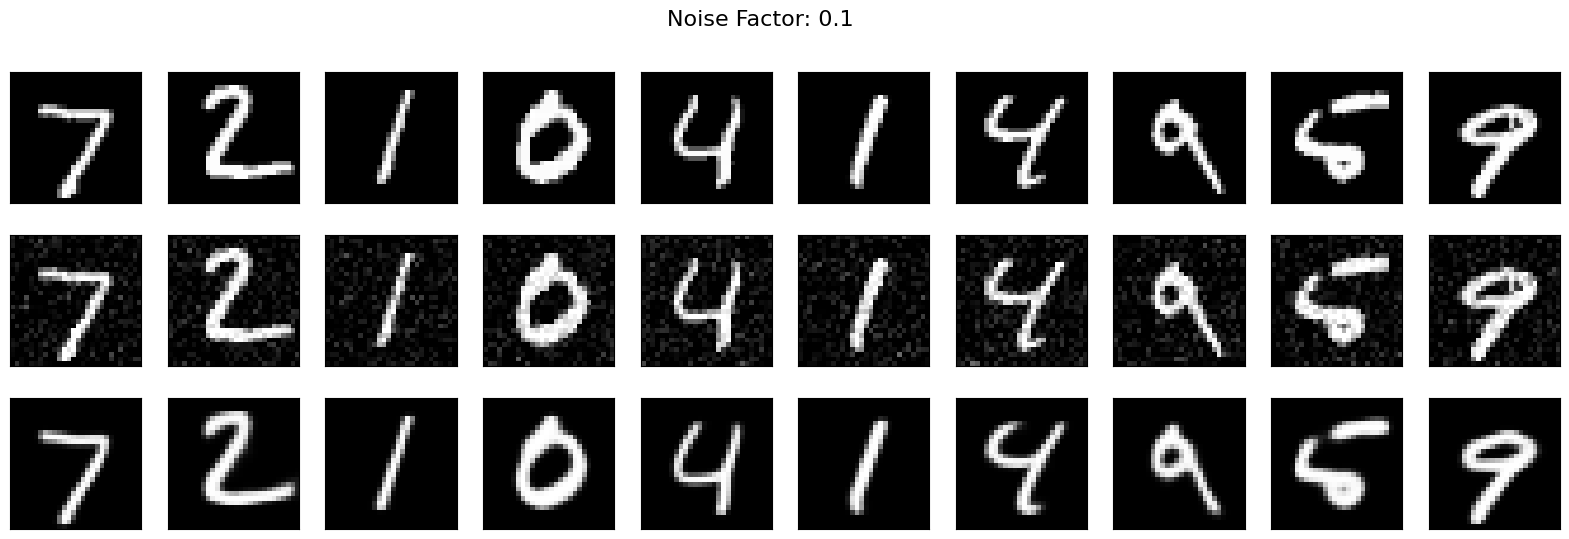

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


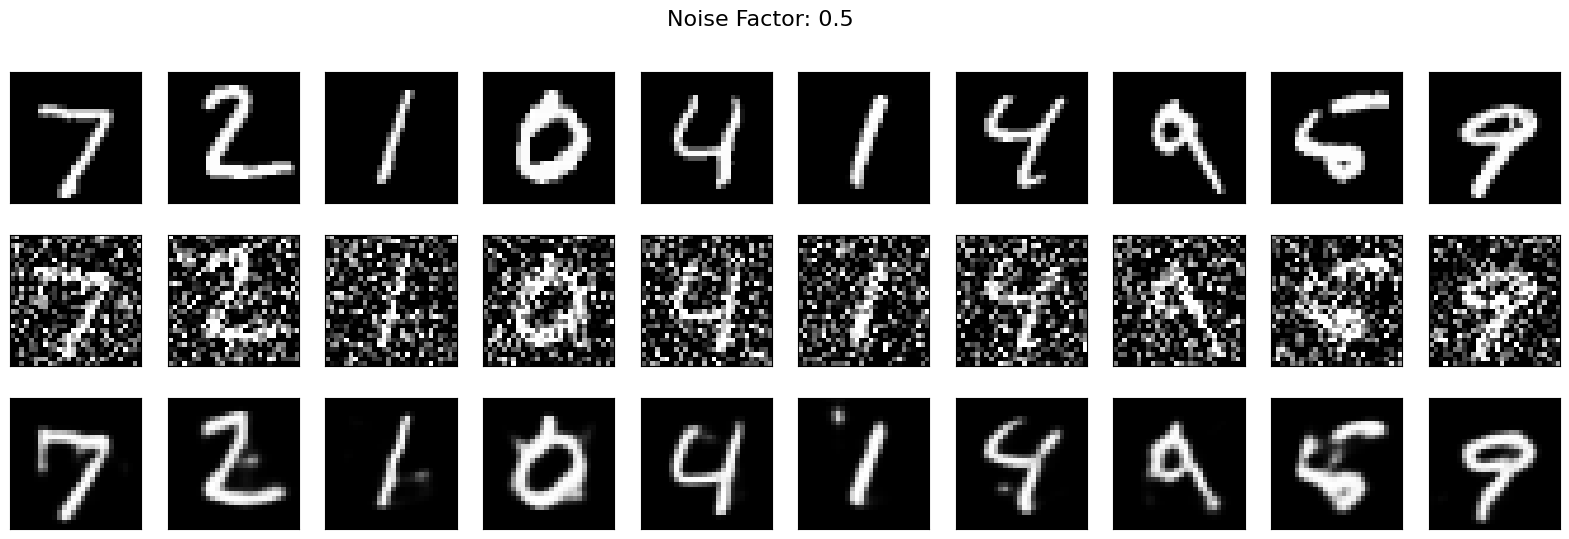

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


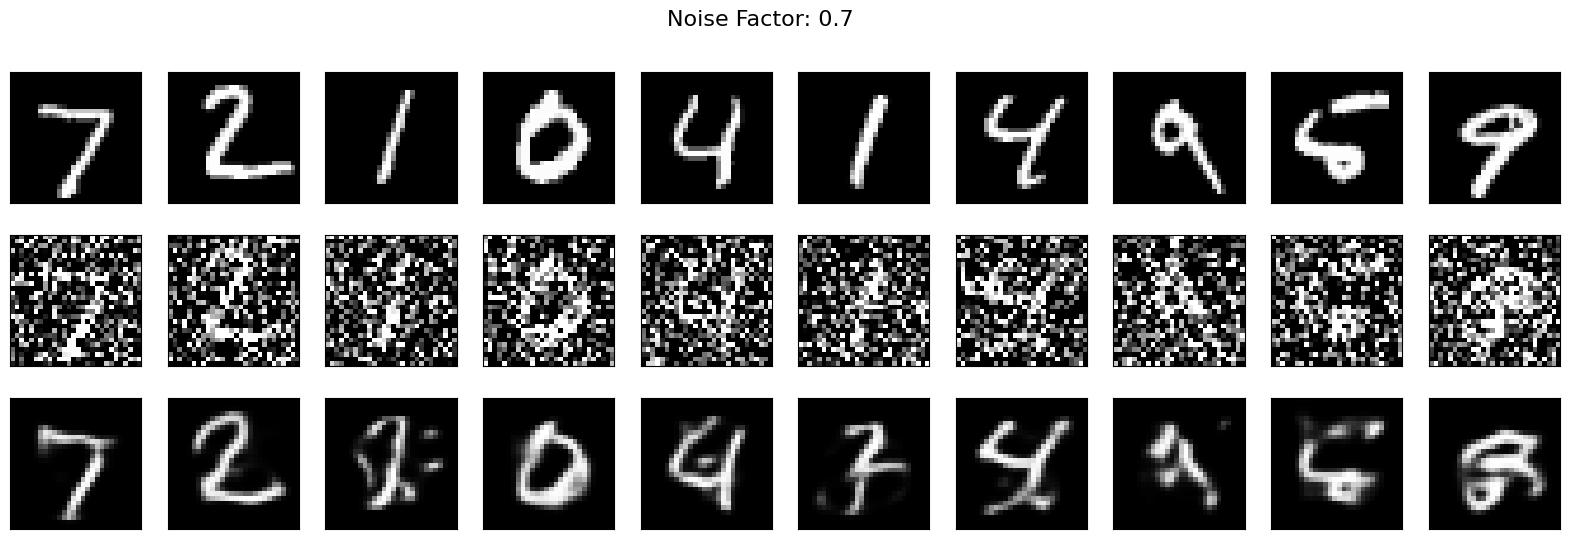

In [10]:
# Noise factors to test
noise_factors = [0.1, 0.5, 0.7]

# Loop through different noise levels
for noise_factor in noise_factors:
    # Add noise to the test data
    x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)

    # Predict denoised images
    denoised_images = diffusion_model.predict(x_test_noisy)

    # Visualize results
    n = 10
    plt.figure(figsize=(20, 6))
    plt.suptitle(f"Noise Factor: {noise_factor}", fontsize=16) # Add title for the noise factor

    for i in range(n):
        # Original image
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_ylabel("Original", rotation=0, labelpad=40)


        # Noisy image
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_ylabel("Noisy", rotation=0, labelpad=40)


        # Denoised image
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_ylabel("Denoised", rotation=0, labelpad=40)

    plt.show()